In [1]:
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

import random, warnings, time
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
from datetime import timedelta
from IPython.display import display
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score
import scipy.stats as st

# HD95
try:
    from medpy.metric.binary import hd95 as _hd95
    HD95_OK = True
except ImportError:
    os.system("pip install medpy -q")
    try:
        from medpy.metric.binary import hd95 as _hd95
        HD95_OK = True
    except:
        HD95_OK = False

try:
    from tqdm.auto import tqdm as tqdm_auto
    _TQDM_OK = True
except ImportError:
    _TQDM_OK = False

import wandb
wandb.login(key="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")
print("All imports OK")
print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
print(f"HD95    : {HD95_OK}")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.3/156.3 kB 6.4 MB/s eta 0:00:00


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: tihami246 (tihami246-brac-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


All imports OK
PyTorch : 2.10.0+cu128
CUDA    : True
GPU     : Tesla T4
HD95    : True


In [2]:
# CELL 2: Config
# ============================================================
#  Dataset 3 — LGG Brain MRI Segmentation
# ============================================================
DATASET_NAME   = "dataset3_lgg"
TRAIN_IMG_DIR  = '/kaggle/input/datasets/ahmadnafeestihami/lgg2d-slices/train/images'
TRAIN_MASK_DIR = '/kaggle/input/datasets/ahmadnafeestihami/lgg2d-slices/train/masks'
TEST_IMG_DIR   = '/kaggle/input/datasets/ahmadnafeestihami/lgg2d-slices/test/images'
TEST_MASK_DIR  = '/kaggle/input/datasets/ahmadnafeestihami/lgg2d-slices/test/masks'
# ============================================================

SEED       = 789
FOLD       = 4
SEEDS      = [789]
K          = 5
IMG_SIZE   = 256
BATCH_SIZE = 16
EPOCHS     = 80
LR         = 1e-4
BASE_CH    = 64
DROPOUT    = 0.3
PATIENCE   = 7

RUN_ID   = "seed789_fold4"
SAVE_DIR = "/kaggle/working/dataset3_lgg_seed789_fold4"
os.makedirs(SAVE_DIR, exist_ok=True)

WANDB_PROJECT  = "iconnet-lgg"
WANDB_RUN_NAME = "seed789_fold4"

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device  : {device}")
print(f"Dataset : {DATASET_NAME}")
print(f"Seed    : {SEED}  |  Fold : {FOLD}  |  Run : {RUN_ID}")

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


Device  : cuda
Dataset : dataset3_lgg
Seed    : 789  |  Fold : 4  |  Run : seed789_fold4


In [3]:
# W&B Init Helper
def init_wandb(run_name):
    run = wandb.init(
        project=WANDB_PROJECT,
        name=run_name,
        config=dict(
            dataset=DATASET_NAME,
            img_size=IMG_SIZE,
            batch_size=BATCH_SIZE,
            epochs=EPOCHS,
            lr=LR,
            base_ch=BASE_CH,
            dropout=DROPOUT,
            patience=PATIENCE,
            seeds=SEEDS,
            k_folds=K,
        ),
    )
    return run


In [4]:
# ── CELL 4: Dataset ──────────────────────────────────────────
class SegDataset(Dataset):
    def __init__(self, img_dir, mask_dir, img_size=256, augment=False):
        self.img_dir   = img_dir
        self.mask_dir  = mask_dir
        self.img_size  = img_size
        self.augment   = augment
        exts = ('.png','.jpg','.jpeg','.tif','.tiff','.bmp')
        self.images = sorted([f for f in os.listdir(img_dir)  if f.lower().endswith(exts)])
        self.masks  = sorted([f for f in os.listdir(mask_dir) if f.lower().endswith(exts)])
        n = min(len(self.images), len(self.masks))
        self.images, self.masks = self.images[:n], self.masks[:n]

    def __len__(self): return len(self.images)

    def __getitem__(self, idx):
        img  = Image.open(os.path.join(self.img_dir,  self.images[idx])).convert('RGB')
        mask = Image.open(os.path.join(self.mask_dir, self.masks[idx])).convert('L')
        img  = img.resize( (self.img_size, self.img_size), Image.BILINEAR)
        mask = mask.resize((self.img_size, self.img_size), Image.NEAREST)

        img_np  = np.array(img,  dtype=np.float32) / 255.0
        mask_np = np.array(mask, dtype=np.float32)
        if mask_np.max() > 1: mask_np /= 255.0
        mask_np = (mask_np > 0.5).astype(np.float32)

        if self.augment:
            if random.random() > 0.5: img_np = np.fliplr(img_np).copy();  mask_np = np.fliplr(mask_np).copy()
            if random.random() > 0.5: img_np = np.flipud(img_np).copy();  mask_np = np.flipud(mask_np).copy()
            if random.random() > 0.5:
                k = random.randint(1,3)
                img_np  = np.rot90(img_np,  k).copy()
                mask_np = np.rot90(mask_np, k).copy()
            if random.random() > 0.5: img_np = np.clip(img_np * random.uniform(0.8,1.2), 0, 1)
            if random.random() > 0.5:
                m = img_np.mean()
                img_np = np.clip((img_np - m) * random.uniform(0.8,1.2) + m, 0, 1)
            if random.random() > 0.7: img_np = np.clip(img_np + np.random.normal(0,0.02,img_np.shape), 0, 1)

        img_t  = torch.from_numpy(img_np).permute(2,0,1).float() * 2 - 1
        mask_t = torch.from_numpy(mask_np).unsqueeze(0).float()
        return img_t, mask_t


In [5]:
# ── CELL 5: Model ────────────────────────────────────────────
class ChannelAttention(nn.Module):
    def __init__(self, c, r=16):
        super().__init__()
        self.avg = nn.AdaptiveAvgPool2d(1)
        self.max = nn.AdaptiveMaxPool2d(1)
        self.fc  = nn.Sequential(nn.Conv2d(c,c//r,1,bias=False), nn.ReLU(True), nn.Conv2d(c//r,c,1,bias=False))
        self.sig = nn.Sigmoid()
    def forward(self,x): return x * self.sig(self.fc(self.avg(x)) + self.fc(self.max(x)))

class SpatialAttention(nn.Module):
    def __init__(self, k=7):
        super().__init__()
        self.conv = nn.Conv2d(2,1,k,padding=k//2,bias=False)
        self.sig  = nn.Sigmoid()
    def forward(self,x):
        return x * self.sig(self.conv(torch.cat([x.mean(1,True), x.max(1,True)[0]], 1)))

class CBAM(nn.Module):
    def __init__(self,c,r=16): super().__init__(); self.ca=ChannelAttention(c,r); self.sa=SpatialAttention()
    def forward(self,x): return self.sa(self.ca(x))

class AttentionGate(nn.Module):
    def __init__(self,Fg,Fl,Fi):
        super().__init__()
        self.Wg  = nn.Sequential(nn.Conv2d(Fg,Fi,1,bias=True), nn.BatchNorm2d(Fi))
        self.Wx  = nn.Sequential(nn.Conv2d(Fl,Fi,1,bias=True), nn.BatchNorm2d(Fi))
        self.psi = nn.Sequential(nn.Conv2d(Fi,1, 1,bias=True), nn.BatchNorm2d(1), nn.Sigmoid())
        self.relu= nn.ReLU(True)
    def forward(self, g, x):
        g_up = F.interpolate(self.Wg(g), size=x.shape[2:], mode='bilinear', align_corners=False)
        return x * self.psi(self.relu(g_up + self.Wx(x)))

class ConvBlock(nn.Module):
    def __init__(self,ic,oc,dr=0.3):
        super().__init__()
        self.c1   = nn.Sequential(nn.Conv2d(ic,oc,3,padding=1,bias=False), nn.BatchNorm2d(oc), nn.ReLU(True), nn.Dropout2d(dr))
        self.c2   = nn.Sequential(nn.Conv2d(oc,oc,3,padding=1,bias=False), nn.BatchNorm2d(oc), nn.ReLU(True), nn.Dropout2d(dr))
        self.cbam = CBAM(oc)
        self.skip = nn.Sequential(nn.Conv2d(ic,oc,1,bias=False), nn.BatchNorm2d(oc)) if ic!=oc else nn.Identity()
    def forward(self,x): return self.cbam(self.c2(self.c1(x))) + self.skip(x)

class ICONNET(nn.Module):
    def __init__(self, ic=3, oc=1, base=64, dr=0.3):
        super().__init__()
        b = base
        self.init   = nn.Sequential(nn.Conv2d(ic,b,3,padding=1,bias=False), nn.BatchNorm2d(b), nn.ReLU(True))
        self.e1=ConvBlock(b,b,dr);    self.p1=nn.MaxPool2d(2)
        self.e2=ConvBlock(b,b*2,dr);  self.p2=nn.MaxPool2d(2)
        self.e3=ConvBlock(b*2,b*4,dr);self.p3=nn.MaxPool2d(2)
        self.e4=ConvBlock(b*4,b*8,dr);self.p4=nn.MaxPool2d(2)
        self.bottleneck = ConvBlock(b*8,b*16,dr)
        self.ag4=AttentionGate(b*16,b*8,b*4)
        self.ag3=AttentionGate(b*8, b*4,b*2)
        self.ag2=AttentionGate(b*4, b*2,b)
        self.ag1=AttentionGate(b*2, b,  b//2)
        self.up4=nn.ConvTranspose2d(b*16,b*8,2,stride=2); self.d4=ConvBlock(b*16,b*8,dr)
        self.up3=nn.ConvTranspose2d(b*8, b*4,2,stride=2); self.d3=ConvBlock(b*8, b*4,dr)
        self.up2=nn.ConvTranspose2d(b*4, b*2,2,stride=2); self.d2=ConvBlock(b*4, b*2,dr)
        self.up1=nn.ConvTranspose2d(b*2, b,  2,stride=2); self.d1=ConvBlock(b*2, b,  dr)
        self.out = nn.Conv2d(b, oc, 1)
        self.ds4 = nn.Conv2d(b*8,oc,1); self.ds3 = nn.Conv2d(b*4,oc,1); self.ds2 = nn.Conv2d(b*2,oc,1)

    def forward(self,x):
        x0 = self.init(x)
        e1 = self.e1(x0); e2 = self.e2(self.p1(e1))
        e3 = self.e3(self.p2(e2)); e4 = self.e4(self.p3(e3))
        bt = self.bottleneck(self.p4(e4))
        d4 = self.d4(torch.cat([self.up4(bt), self.ag4(bt,e4)],1))
        d3 = self.d3(torch.cat([self.up3(d4), self.ag3(d4,e3)],1))
        d2 = self.d2(torch.cat([self.up2(d3), self.ag2(d3,e2)],1))
        d1 = self.d1(torch.cat([self.up1(d2), self.ag1(d2,e1)],1))
        main = torch.sigmoid(self.out(d1))
        if self.training:
            s = x.shape[2:]
            ds4 = torch.sigmoid(F.interpolate(self.ds4(d4), s, mode='bilinear', align_corners=False))
            ds3 = torch.sigmoid(F.interpolate(self.ds3(d3), s, mode='bilinear', align_corners=False))
            ds2 = torch.sigmoid(F.interpolate(self.ds2(d2), s, mode='bilinear', align_corners=False))
            return main, ds4, ds3, ds2
        return main


In [6]:
# ── CELL 6: Loss ─────────────────────────────────────────────
class CombinedLoss(nn.Module):
    def __init__(self, dw=0.5, bw=0.3, fw=0.2, smooth=1e-6):
        super().__init__(); self.dw=dw; self.bw=bw; self.fw=fw; self.s=smooth

    def dice(self,p,t):
        pf,tf = p.view(-1), t.view(-1)
        return 1-(2*(pf*tf).sum()+self.s)/(pf.sum()+tf.sum()+self.s)

    def focal(self,p,t,a=0.25,g=2.0):
        bce = F.binary_cross_entropy(p,t,reduction='none')
        return (a*(1-torch.exp(-bce))**g*bce).mean()

    def forward(self,p,t):
        bce = F.binary_cross_entropy(p,t)
        return self.dw*self.dice(p,t) + self.bw*bce + self.fw*self.focal(p,t)


In [7]:
# ── CELL 7: Metrics + HD95 + 95% CI ─────────────────────────
def compute_hd95(pred_bin, gt_bin):
    if not HD95_OK: return float('nan')
    try:
        p = pred_bin.astype(bool); g = gt_bin.astype(bool)
        if not p.any() or not g.any(): return float('nan')
        return float(_hd95(p, g))
    except Exception:
        return float('nan')

def compute_metrics(preds_prob, targets, threshold=0.5):
    preds = (preds_prob > threshold).astype(np.uint8)
    tflat = targets.astype(np.uint8).flatten()
    pflat = preds.flatten()
    tp = np.sum((pflat==1)&(tflat==1)); tn = np.sum((pflat==0)&(tflat==0))
    fp = np.sum((pflat==1)&(tflat==0)); fn = np.sum((pflat==0)&(tflat==1))
    smooth = 1e-6
    dice = (2*tp+smooth)/(2*tp+fp+fn+smooth)
    iou  = (tp+smooth)/(tp+fp+fn+smooth)
    acc  = (tp+tn+smooth)/(tp+tn+fp+fn+smooth)
    prec = (tp+smooth)/(tp+fp+smooth)
    rec  = (tp+smooth)/(tp+fn+smooth)
    spec = (tn+smooth)/(tn+fp+smooth)
    f1   = (2*prec*rec+smooth)/(prec+rec+smooth)
    try:    auc_roc = roc_auc_score(tflat, preds_prob.flatten())
    except: auc_roc = 0.0
    try:    auc_pr  = average_precision_score(tflat, preds_prob.flatten())
    except: auc_pr  = 0.0
    hd_vals = []
    for i in range(preds_prob.shape[0]):
        p2d = preds[i,0] if preds.ndim==4 else preds[i]
        g2d = targets.astype(np.uint8)[i,0] if targets.ndim==4 else targets.astype(np.uint8)[i]
        hd_vals.append(compute_hd95(p2d, g2d))
    hd95_mean = float(np.nanmean(hd_vals)) if hd_vals else float('nan')
    return dict(dice=dice, iou=iou, accuracy=acc, precision=prec,
                recall=rec, specificity=spec, f1=f1,
                auc_roc=auc_roc, auc_pr=auc_pr, hd95=hd95_mean)

def compute_ci95(scores):
    scores = [s for s in scores if not np.isnan(s)]
    if len(scores) < 2: return float('nan'), float('nan')
    lo, hi = st.t.interval(0.95, df=len(scores)-1,
                            loc=np.mean(scores), scale=st.sem(scores))
    return float(lo), float(hi)


In [8]:
# CELL 8: Train / Eval Epoch — tqdm batch bar with plain-print fallback
try:
    from tqdm.auto import tqdm as _tqdm
    def _make_bar(loader, desc):
        return _tqdm(loader, desc=desc, leave=False,
                     bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}]")
except Exception:
    def _make_bar(loader, desc):
        return loader

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0; all_p = []; all_t = []
    total_grad_norm = 0; n_batches = 0
    for imgs, masks in _make_bar(loader, "train"):
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        out = model(imgs)
        if isinstance(out, tuple):
            main, ds4, ds3, ds2 = out
            loss = (criterion(main, masks) * 0.6 +
                    criterion(ds4,  masks) * 0.2 +
                    criterion(ds3,  masks) * 0.1 +
                    criterion(ds2,  masks) * 0.1)
        else:
            main = out
            loss = criterion(main, masks)
        loss.backward()
        # ── Gradient norm (R1#11) ──
        total_norm = 0
        for p in model.parameters():
            if p.grad is not None:
                total_norm += p.grad.norm(2).item() ** 2
        total_grad_norm += total_norm ** 0.5
        n_batches += 1
        optimizer.step()
        total_loss += loss.item()
        all_p.append(main.detach().cpu().numpy())
        all_t.append(masks.cpu().numpy())
    preds = np.concatenate(all_p)
    tgts  = np.concatenate(all_t)
    avg_grad_norm = total_grad_norm / max(n_batches, 1)
    return total_loss / len(loader), compute_metrics(preds, tgts), avg_grad_norm

@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0; all_p = []; all_t = []
    for imgs, masks in _make_bar(loader, "val  "):
        imgs, masks = imgs.to(device), masks.to(device)
        out  = model(imgs)
        loss = criterion(out, masks)
        total_loss += loss.item()
        all_p.append(out.cpu().numpy())
        all_t.append(masks.cpu().numpy())
    preds = np.concatenate(all_p)
    tgts  = np.concatenate(all_t)
    return total_loss / len(loader), compute_metrics(preds, tgts)

@torch.no_grad()
def eval_with_tta(model, loader, device):
    """TTA: avg of original + hflip + vflip + rot90 (R1#32)"""
    model.eval()
    all_p = []; all_t = []
    for imgs, masks in _make_bar(loader, "tta  "):
        imgs = imgs.to(device)
        p0  = model(imgs)
        p1  = model(torch.flip(imgs, [3]))
        p2  = model(torch.flip(imgs, [2]))
        p3  = model(torch.rot90(imgs, 1, [2,3]))
        p1b = torch.flip(p1, [3])
        p2b = torch.flip(p2, [2])
        p3b = torch.rot90(p3, -1, [2,3])
        avg = (p0 + p1b + p2b + p3b) / 4.0
        all_p.append(avg.cpu().numpy())
        all_t.append(masks.numpy())
    return np.concatenate(all_p), np.concatenate(all_t)

def measure_vram_mb():
    if torch.cuda.is_available():
        return torch.cuda.max_memory_allocated() / 1024**2
    return float('nan')


In [9]:
# ── CELL 8b: Plotting Utilities ──────────────────────────────
def plot_all_curves(history, run_id, save_dir):
    tr = history['train']; vl = history['val']; gn = history['grad_norm']
    epochs = list(range(1, len(tr)+1))

    def get(split, key):
        src = tr if split=='train' else vl
        return [e.get(key, float('nan')) for e in src]

    def save_show(fig, name):
        path  = f'/kaggle/working/{name}_{run_id}.png'
        path2 = f'{save_dir}/{name}_{run_id}.png'
        fig.savefig(path,  dpi=110, bbox_inches='tight')
        fig.savefig(path2, dpi=110, bbox_inches='tight')
        display(fig)
        plt.close(fig)
        print(f'  Saved: {name}_{run_id}.png')

    C = {'tr':'#2196F3','vl':'#FF5722','dice':'#4CAF50','iou':'#9C27B0',
         'prec':'#F44336','rec':'#FF9800','f1':'#03A9F4','spec':'#795548',
         'roc':'#009688','pr':'#E91E63','gn':'#607D8B'}

    # Plot 1: Accuracy & Loss
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(f'Accuracy & Loss — {run_id}', fontweight='bold')
    axes[0].plot(epochs, get('train','accuracy'), color=C['tr'], label='Train Acc')
    axes[0].plot(epochs, get('val',  'accuracy'), color=C['vl'], label='Val Acc', linestyle='--')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy'); axes[0].set_title('Model Accuracy')
    axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(epochs, get('train','loss'), color=C['tr'], label='Training Loss')
    axes[1].plot(epochs, get('val',  'loss'), color=C['vl'], label='Validation Loss', linestyle='--')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss'); axes[1].set_title('Model Loss')
    axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout(); save_show(fig, 'curves_acc_loss')

    # Plot 2: Dice & IoU
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(f'Dice & IoU — {run_id}', fontweight='bold')
    axes[0].plot(epochs, get('train','dice'), color=C['tr'],   label='Train Dice')
    axes[0].plot(epochs, get('val',  'dice'), color=C['vl'],   label='Val Dice',   linestyle='--')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Dice'); axes[0].set_title('Dice Coefficient')
    axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(epochs, get('train','iou'),  color=C['dice'], label='Train IoU')
    axes[1].plot(epochs, get('val',  'iou'),  color=C['iou'],  label='Val IoU',    linestyle='--')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('IoU'); axes[1].set_title('Intersection over Union')
    axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout(); save_show(fig, 'curves_dice_iou')

    # Plot 3: Prec / Rec / F1 / Spec
    fig, axes = plt.subplots(2, 2, figsize=(13, 8))
    fig.suptitle(f'Precision / Recall / F1 / Specificity — {run_id}', fontweight='bold')
    for ax, key, title, col in [
        (axes[0,0],'precision','Precision',C['prec']),
        (axes[0,1],'recall',   'Recall',   C['rec']),
        (axes[1,0],'f1',       'F1 Score', C['f1']),
        (axes[1,1],'specificity','Specificity',C['spec']),
    ]:
        ax.plot(epochs, get('train',key), color=C['tr'], label='Train')
        ax.plot(epochs, get('val',  key), color=col,     label='Val', linestyle='--')
        ax.set_xlabel('Epoch'); ax.set_ylabel(title); ax.set_title(title)
        ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); save_show(fig, 'curves_prec_rec_f1_spec')

    # Plot 4: AUC-ROC & AUC-PR
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(f'AUC Curves — {run_id}', fontweight='bold')
    axes[0].plot(epochs, get('val','auc_roc'), color=C['roc'], label='Val AUC-ROC')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('AUC-ROC'); axes[0].set_title('AUC-ROC over Training')
    axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(epochs, get('val','auc_pr'),  color=C['pr'],  label='Val AUC-PR')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('AUC-PR'); axes[1].set_title('AUC-PR over Training')
    axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout(); save_show(fig, 'curves_auc')

    # Plot 5: Gradient Norm
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(epochs[:len(gn)], gn, color=C['gn'], linewidth=1.2)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Gradient L2 Norm')
    ax.set_title(f'Gradient Norm — {run_id}'); ax.grid(alpha=0.3)
    plt.tight_layout(); save_show(fig, 'curves_grad_norm')

    # Plot 6: HD95 over epochs
    hd_vals = get('val','hd95')
    if any(not np.isnan(v) for v in hd_vals):
        fig, ax = plt.subplots(figsize=(10, 3))
        ax.plot(epochs, hd_vals, color='#FF5722', linewidth=1.2)
        ax.set_xlabel('Epoch'); ax.set_ylabel('HD95 (pixels)')
        ax.set_title(f'HD95 (lower=better) — {run_id}'); ax.grid(alpha=0.3)
        plt.tight_layout(); save_show(fig, 'curves_hd95')

    # Plot 7: Full dashboard
    fig = plt.figure(figsize=(18, 10))
    fig.suptitle(f'Full Training Dashboard — {run_id}', fontsize=13, fontweight='bold')
    gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.35)
    metrics = [
        (gs[0,0],'loss',       'Loss',       C['tr'],C['vl']),
        (gs[0,1],'accuracy',   'Accuracy',   C['tr'],C['vl']),
        (gs[0,2],'dice',       'Dice',       C['tr'],C['vl']),
        (gs[0,3],'iou',        'IoU',        C['tr'],C['vl']),
        (gs[1,0],'precision',  'Precision',  C['tr'],C['prec']),
        (gs[1,1],'recall',     'Recall',     C['tr'],C['rec']),
        (gs[1,2],'f1',         'F1',         C['tr'],C['f1']),
        (gs[1,3],'specificity','Specificity',C['tr'],C['spec']),
        (gs[2,0],'auc_roc',   'AUC-ROC',    None,   C['roc']),
        (gs[2,1],'auc_pr',    'AUC-PR',     None,   C['pr']),
    ]
    for slot, key, title, tc, vc in metrics:
        ax = fig.add_subplot(slot)
        if tc: ax.plot(epochs, get('train',key), color=tc, lw=1.0, label='Tr')
        ax.plot(epochs, get('val',key), color=vc, lw=1.0, linestyle='--', label='Val')
        ax.set_title(title, fontsize=9); ax.legend(fontsize=7); ax.grid(alpha=0.2)
        ax.tick_params(labelsize=7)
    ax = fig.add_subplot(gs[2,2])
    ax.plot(epochs[:len(gn)], gn, color=C['gn'], lw=1.0)
    ax.set_title('Grad Norm', fontsize=9); ax.grid(alpha=0.2); ax.tick_params(labelsize=7)
    save_show(fig, 'dashboard_full')
    print("  All plots generated.")


In [10]:
# CELL 9: Single Run — seed=789 fold=4
def run_single(train_idx, val_idx, test_dataset, full_dataset, seed, fold, run_id):
    print(f"\n" + "="*60)
    print(f"  {run_id}  |  Seed={seed}  Fold={fold}")
    print("="*60)
    set_seed(seed)
    run_start = time.time()

    run = init_wandb(run_id)

    train_ds = Subset(full_dataset, train_idx)
    val_ds   = Subset(full_dataset, val_idx)
    train_ds.dataset.augment = True

    train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True,  num_workers=4, pin_memory=True, persistent_workers=True)
    val_loader   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True)
    test_loader  = DataLoader(test_dataset, BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True)

    torch.cuda.reset_peak_memory_stats()

    model     = ICONNET(base=BASE_CH, dr=DROPOUT).to(device)
    wandb.watch(model, log="all", log_freq=50)
    print(f"  GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else chr(67)+chr(80)+chr(85)}")
    criterion = CombinedLoss()
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-5)
    scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2, eta_min=1e-6)

    best_val_dice = 0
    patience_ctr  = 0
    ckpt_path = f"{SAVE_DIR}/best_seed789_fold4.pth"
    history   = {'train': [], 'val': [], 'grad_norm': []}

    print(f"  Training for up to {EPOCHS} epochs (patience={PATIENCE})")
    print(f"  Batch={BATCH_SIZE}  LR={LR}  Workers=4")
    print()

    try:
        from tqdm.auto import tqdm as _tqdm
        epoch_bar = _tqdm(range(EPOCHS), desc="Epochs", unit="ep")
    except Exception:
        epoch_bar = range(EPOCHS)

    for epoch in epoch_bar:
        tr_loss, tr_m, grad_norm = train_epoch(model, train_loader, criterion, optimizer, device)
        vl_loss, vl_m            = eval_epoch(model, val_loader,   criterion, device)
        scheduler.step()

        history['train'].append({**tr_m, 'loss': tr_loss})
        history['val'].append({**vl_m,   'loss': vl_loss})
        history['grad_norm'].append(grad_norm)

        wandb.log({
            'epoch':      epoch + 1,
            'lr':         optimizer.param_groups[0]['lr'],
            'grad_norm':  grad_norm,
            'train/loss': tr_loss,
            **{f'train/{k}': v for k, v in tr_m.items()},
            'val/loss':   vl_loss,
            **{f'val/{k}':   v for k, v in vl_m.items()},
        }, step=epoch + 1)

        status = (f"TrDice={tr_m['dice']:.4f} VlDice={vl_m['dice']:.4f} "
                  f"IoU={vl_m['iou']:.4f} Pat={patience_ctr}/{PATIENCE}")
        if hasattr(epoch_bar, 'set_postfix_str'):
            epoch_bar.set_postfix_str(status)
        else:
            elapsed = time.time() - run_start
            print(f"  Ep{epoch+1:3d}/{EPOCHS} | {status} | Elapsed={str(timedelta(seconds=int(elapsed)))}")

        if vl_m['dice'] > best_val_dice:
            best_val_dice = vl_m['dice']
            patience_ctr  = 0
            torch.save(model.state_dict(), ckpt_path)
            wandb.run.summary['best_val_dice'] = best_val_dice
        else:
            patience_ctr += 1
            if patience_ctr >= PATIENCE:
                if hasattr(epoch_bar, 'close'): epoch_bar.close()
                print(f"  Early stop at epoch {epoch+1}")
                break

    run_elapsed = time.time() - run_start
    print(f"\n  Run time: {str(timedelta(seconds=int(run_elapsed)))}")

    vram_peak_mb = measure_vram_mb()
    print(f"  Peak VRAM: {vram_peak_mb:.1f} MB")

    model.load_state_dict(torch.load(ckpt_path, map_location=device))

    te_loss, te_m    = eval_epoch(model, test_loader, criterion, device)
    tta_preds, tta_t = eval_with_tta(model, test_loader, device)
    te_m_tta         = compute_metrics(tta_preds, tta_t)

    print(f"\n  RESULTS (standard)")
    print(f"  Val  Dice : {best_val_dice:.4f}")
    print(f"  Test Dice : {te_m['dice']:.4f}  IoU: {te_m['iou']:.4f}  HD95: {te_m.get('hd95',float('nan')):.2f}  AUC: {te_m['auc_roc']:.4f}")
    print(f"\n  RESULTS (TTA)")
    print(f"  TTA  Dice : {te_m_tta['dice']:.4f}  IoU: {te_m_tta['iou']:.4f}  HD95: {te_m_tta.get('hd95',float('nan')):.2f}")
    print(f"  VRAM Peak : {vram_peak_mb:.1f} MB")

    print("\n  Generating training curves...")
    plot_all_curves(history, run_id, SAVE_DIR)

    wandb.log({
        **{f'test/{k}': v for k, v in te_m.items()},
        'test/loss': te_loss,
        **{f'test_tta/{k}': v for k, v in te_m_tta.items()},
        'vram_peak_mb': vram_peak_mb,
    })
    artifact = wandb.Artifact(
        name=f'model-{run_id}', type='model',
        description=f'Best checkpoint for {run_id}',
        metadata={'val_dice': best_val_dice, **{f'test_{k}': v for k, v in te_m.items()}},
    )
    artifact.add_file(ckpt_path)
    wandb.log_artifact(artifact)
    wandb.finish()

    return {
        'run_id':          run_id,
        'dataset':         DATASET_NAME,
        'seed':            seed,
        'fold':            fold,
        'run_time_s':      round(run_elapsed, 1),
        'vram_peak_mb':    round(vram_peak_mb, 1),
        **{f'train_{k}': v for k, v in history['train'][-1].items()},
        'val_dice':        best_val_dice,
        **{f'val_{k}': v for k, v in history['val'][-1].items()},
        **{f'test_{k}': v for k, v in te_m.items()},
        'test_loss':       te_loss,
        **{f'test_tta_{k}': v for k, v in te_m_tta.items()},
        'grad_norm_final': history['grad_norm'][-1] if history['grad_norm'] else float('nan'),
    }, history


  Dataset : dataset3_lgg
  Seed    : 789  |  Fold : 4
  Train   : 2674 samples
  Val     : 668 samples
  Test    : 587 samples

  seed789_fold4  |  Seed=789  Fold=4


wandb: Tracking run with wandb version 0.25.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260606_204637-80dry55o
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run seed789_fold4
wandb: ⭐️ View project at https://wandb.ai/tihami246-brac-university/iconnet-lgg
wandb: 🚀 View run at https://wandb.ai/tihami246-brac-university/iconnet-lgg/runs/80dry55o


  GPU: Tesla T4
  Training for up to 80 epochs (patience=7)
  Batch=16  LR=0.0001  Workers=4



Epochs:   0%|          | 0/80 [00:00<?, ?ep/s]

train:   0%|          | 0/168 [00:00<?, ?it/s]

...

val  :   0%|          | 0/42 [00:00<?, ?it/s]

  Early stop at epoch 37

  Run time: 7:24:58
  Peak VRAM: 12377.7 MB


val  :   0%|          | 0/37 [00:00<?, ?it/s]

tta  :   0%|          | 0/37 [00:00<?, ?it/s]


  RESULTS (standard)
  Val  Dice : 0.8425
  Test Dice : 0.8326  IoU: 0.7132  HD95: 9.61  AUC: 0.9868

  RESULTS (TTA)
  TTA  Dice : 0.8340  IoU: 0.7153  HD95: 9.72
  VRAM Peak : 12377.7 MB

  Generating training curves...


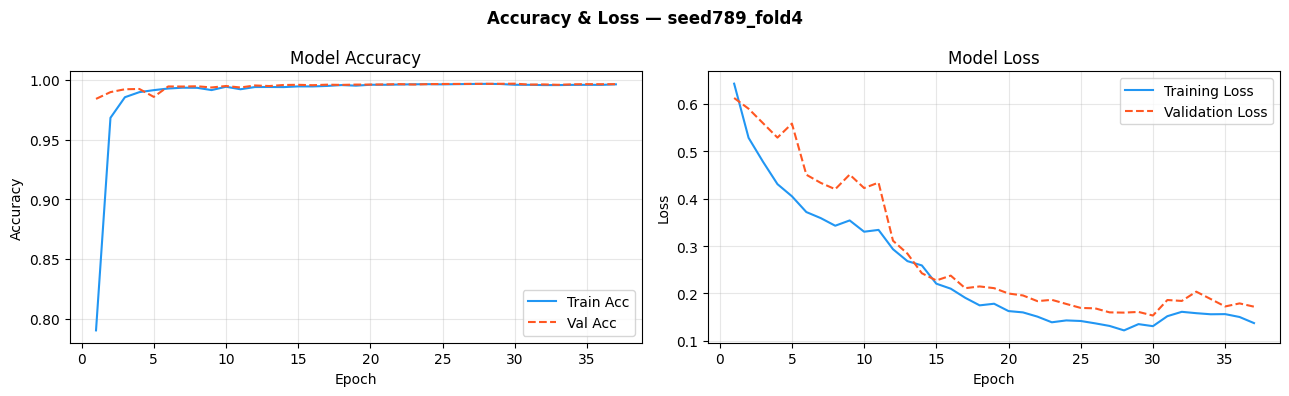

  Saved: curves_acc_loss_seed789_fold4.png


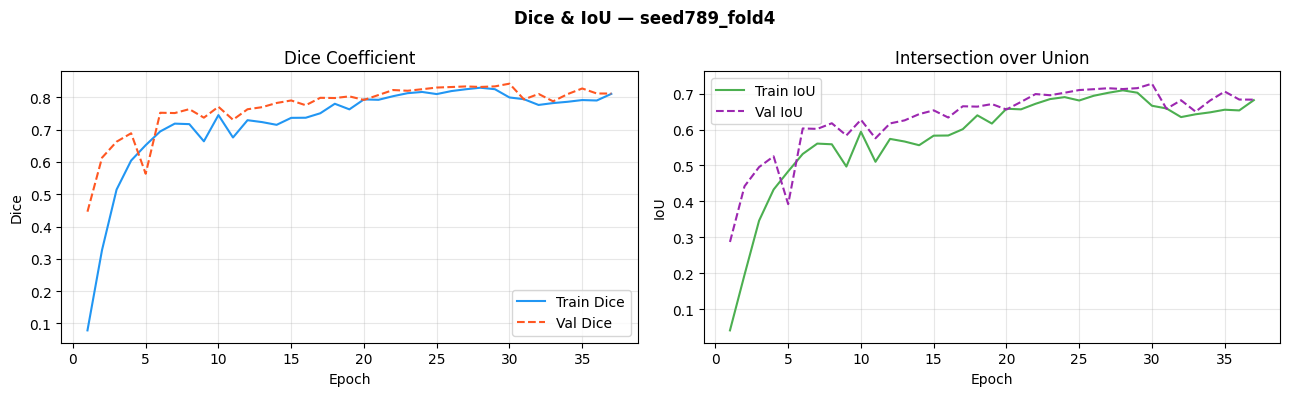

  Saved: curves_dice_iou_seed789_fold4.png


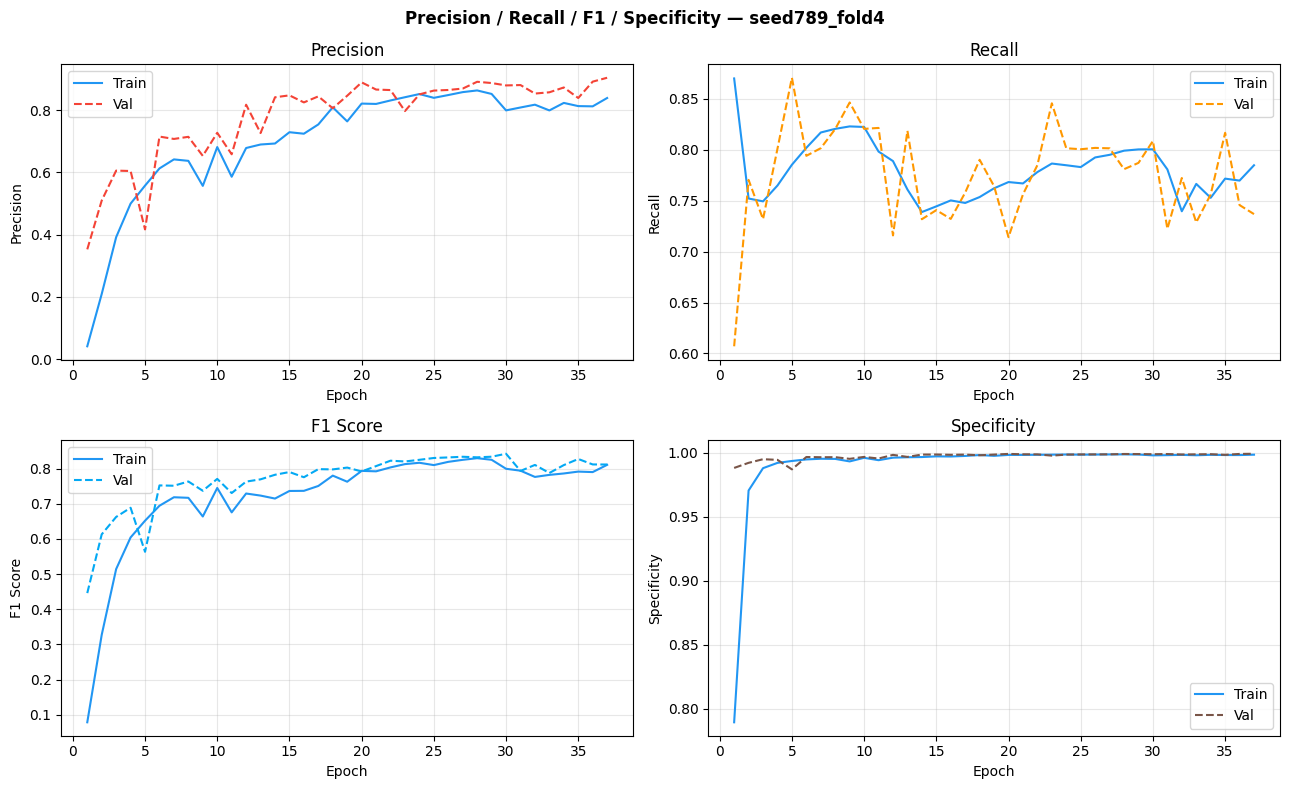

  Saved: curves_prec_rec_f1_spec_seed789_fold4.png


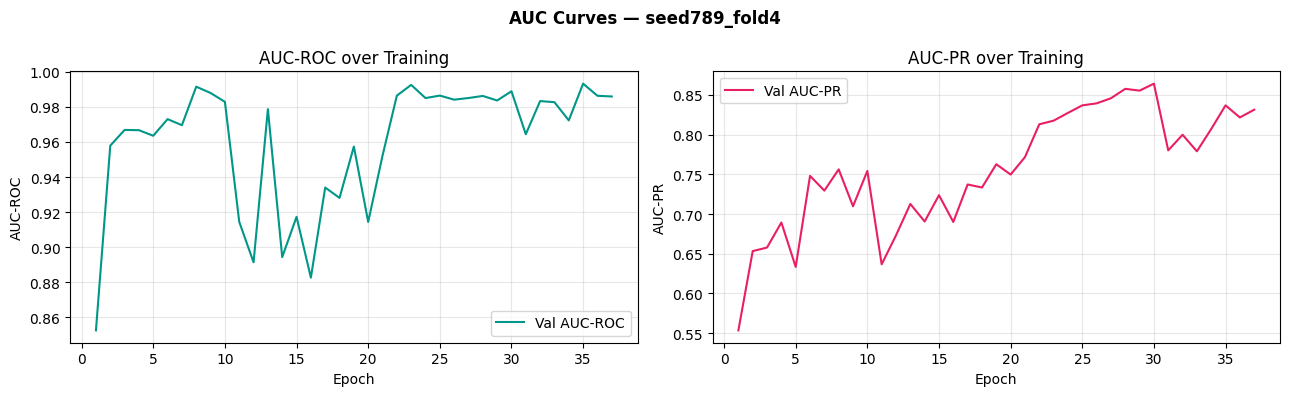

  Saved: curves_auc_seed789_fold4.png


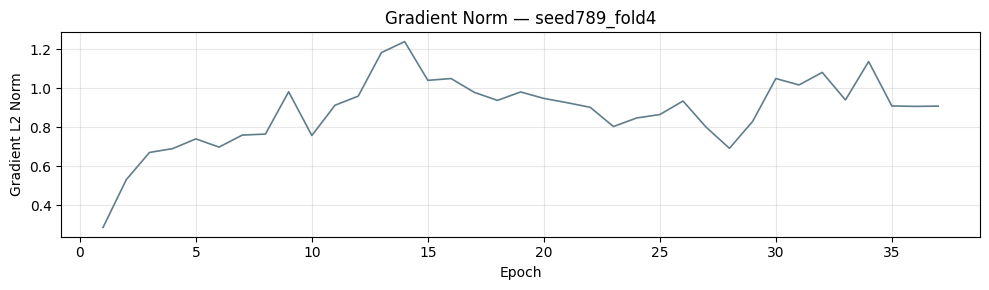

  Saved: curves_grad_norm_seed789_fold4.png


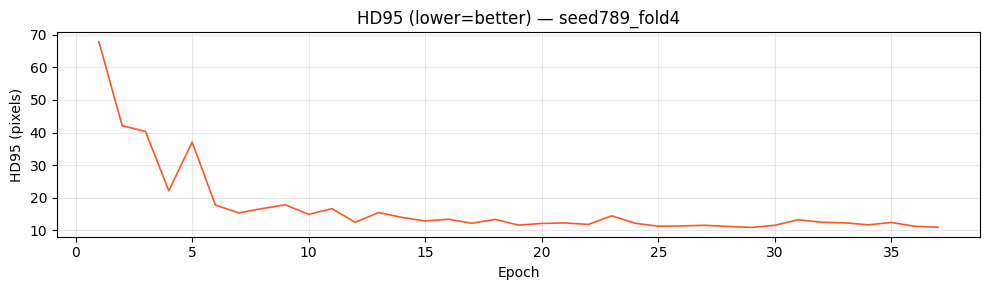

  Saved: curves_hd95_seed789_fold4.png


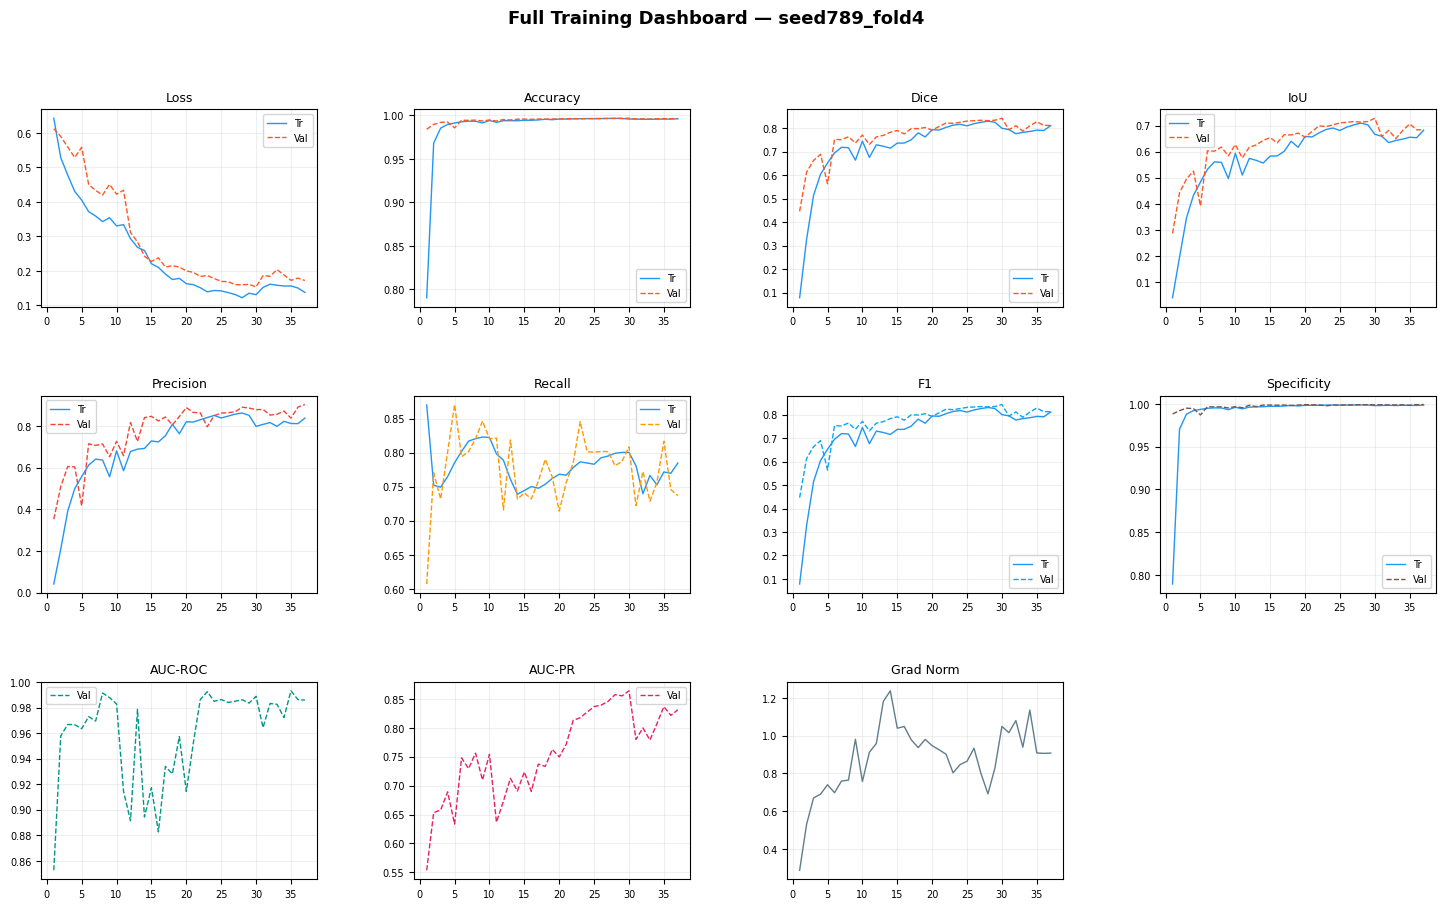

  Saved: dashboard_full_seed789_fold4.png
  All plots generated.


wandb: uploading artifact model-seed789_fold4; updating run metadata
wandb: uploading artifact model-seed789_fold4; uploading history steps 37-37, summary, console lines 8-25
wandb: uploading artifact model-seed789_fold4
wandb: 
wandb: Run history:
wandb:         epoch ▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇███
wandb:     grad_norm ▁▃▄▄▄▄▄▅▆▄▆▆██▇▇▆▆▆▆▆▆▅▅▅▆▅▄▅▇▆▇▆▇▆▆▆
wandb:            lr █▇▇▆▄▃▂▂▁████▇▇▇▆▆▅▄▄▃▃▂▂▂▁▁▁███████▇
wandb: test/accuracy ▁
wandb:   test/auc_pr ▁
wandb:  test/auc_roc ▁
wandb:     test/dice ▁
wandb:       test/f1 ▁
wandb:     test/hd95 ▁
wandb:      test/iou ▁
wandb:           +37 ...
wandb: 
wandb: Run summary:
wandb: best_val_dice 0.84246
wandb:         epoch 37
wandb:     grad_norm 0.90739
wandb:            lr 9e-05
wandb: test/accuracy 0.99668
wandb:   test/auc_pr 0.83466
wandb:  test/auc_roc 0.98676
wandb:     test/dice 0.83261
wandb:       test/f1 0.83261
wandb:     test/hd95 9.60774
wandb:           +38 ...
wandb: 
wandb: 🚀 View run seed789_fold4 at: https://

CSV saved -> result_seed789_fold4.csv
PTH saved -> best_seed789_fold4.pth

  DONE  seed=789  fold=4
  Test Dice     : 0.8326
  Test IoU      : 0.7132
  Test Prec     : 0.8425
  Test Recall   : 0.8229
  Test Spec     : 0.9984
  Test F1       : 0.8326
  Test HD95     : 9.61
  Test AUC-ROC  : 0.9868
  Test AUC-PR   : 0.8347
  TTA  Dice     : 0.8340
  TTA  IoU      : 0.7153
  TTA  HD95     : 9.72
  Val  Dice     : 0.8119
  VRAM Peak     : 12377.7 MB
  Total time    : 7:28:06

  FULL RESULTS TABLE — copy-paste if CSV download fails
  run_id                              : seed789_fold4
  dataset                             : dataset3_lgg
  seed                                : 789
  fold                                : 4
  run_time_s                          : 26698.100000
  vram_peak_mb                        : 12377.700000
  train_dice                          : 0.810902
  train_iou                           : 0.681947
  train_accuracy                      : 0.996235
  train_precision    

In [11]:
# CELL 10: MAIN LOOP — seed=789 fold=4
SEED = 789
FOLD = 4

full_train_ds = SegDataset(TRAIN_IMG_DIR, TRAIN_MASK_DIR, IMG_SIZE, augment=False)
test_ds       = SegDataset(TEST_IMG_DIR,  TEST_MASK_DIR,  IMG_SIZE, augment=False)
dummy_labels  = np.arange(len(full_train_ds)) % 3

skf    = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
splits = list(skf.split(np.zeros(len(full_train_ds)), dummy_labels))
tr_idx, vl_idx = splits[FOLD - 1]
run_id = RUN_ID

print('=' * 60)
print('  Dataset : ' + DATASET_NAME)
print(f'  Seed    : 789  |  Fold : 4')
print(f'  Train   : {len(tr_idx)} samples')
print(f'  Val     : {len(vl_idx)} samples')
print(f'  Test    : {len(test_ds)} samples')
print('=' * 60)

global_start = time.time()
all_results  = []

result, history = run_single(tr_idx, vl_idx, test_ds, full_train_ds, SEED, FOLD, run_id)
all_results.append(result)

import shutil
csv_path = f'/kaggle/working/result_seed789_fold4.csv'
pth_path = f'/kaggle/working/best_seed789_fold4.pth'

pd.DataFrame(all_results).to_csv(csv_path, index=False)
print(f'CSV saved -> result_seed789_fold4.csv')

pth_src = f'{SAVE_DIR}/best_seed789_fold4.pth'
if os.path.exists(pth_src):
    shutil.copy(pth_src, pth_path)
    print(f'PTH saved -> best_seed789_fold4.pth')
else:
    pths = [f for f in os.listdir(SAVE_DIR) if f.endswith('.pth')]
    if pths:
        shutil.copy(os.path.join(SAVE_DIR, pths[0]), pth_path)
        print('PTH saved (fallback)')
    else:
        print('WARNING: No .pth found!')

total_time = time.time() - global_start
print()
print('=' * 60)
print(f'  DONE  seed=789  fold=4')
print('=' * 60)
print(f"  Test Dice     : {result['test_dice']:.4f}")
print(f"  Test IoU      : {result['test_iou']:.4f}")
print(f"  Test Prec     : {result['test_precision']:.4f}")
print(f"  Test Recall   : {result['test_recall']:.4f}")
print(f"  Test Spec     : {result['test_specificity']:.4f}")
print(f"  Test F1       : {result['test_f1']:.4f}")
print(f"  Test HD95     : {result.get('test_hd95', float('nan')):.2f}")
print(f"  Test AUC-ROC  : {result['test_auc_roc']:.4f}")
print(f"  Test AUC-PR   : {result['test_auc_pr']:.4f}")
print(f"  TTA  Dice     : {result['test_tta_dice']:.4f}")
print(f"  TTA  IoU      : {result['test_tta_iou']:.4f}")
print(f"  TTA  HD95     : {result.get('test_tta_hd95', float('nan')):.2f}")
print(f"  Val  Dice     : {result['val_dice']:.4f}")
print(f"  VRAM Peak     : {result['vram_peak_mb']:.1f} MB")
print(f'  Total time    : {str(timedelta(seconds=int(total_time)))}')
print()

# ── FULL RESULTS TABLE — copy-paste if CSV download fails ──
print('=' * 60)
print('  FULL RESULTS TABLE — copy-paste if CSV download fails')
print('=' * 60)
df = pd.DataFrame(all_results)
for col in df.columns:
    val = df[col].iloc[0]
    if isinstance(val, float):
        print(f"  {col:<35} : {val:.6f}")
    else:
        print(f"  {col:<35} : {val}")
print()
print('  RAW CSV — HEADERS:')
print('  ' + ','.join(str(c) for c in df.columns))
print('  RAW CSV — VALUES:')
print('  ' + ','.join(str(round(v,6) if isinstance(v,float) else v) for v in df.iloc[0]))


In [12]:
# CELL 11: Verify output files are downloadable
import os, glob
working = '/kaggle/working'
print('Output files (download from Output tab):')
for fpath in sorted(glob.glob(f'{working}/*.png') +
                    glob.glob(f'{working}/*.csv') +
                    glob.glob(f'{working}/*.pth')):
    size_mb = os.path.getsize(fpath) / 1024 / 1024
    print(f'  READY  {os.path.basename(fpath):<50} {size_mb:.2f} MB')
print()
print('Go to Output tab -> click download arrow next to each file')


Output files (download from Output tab):
  READY  best_seed789_fold4.pth                             126.89 MB
  READY  curves_acc_loss_seed789_fold4.png                  0.06 MB
  READY  curves_auc_seed789_fold4.png                       0.08 MB
  READY  curves_dice_iou_seed789_fold4.png                  0.07 MB
  READY  curves_grad_norm_seed789_fold4.png                 0.03 MB
  READY  curves_hd95_seed789_fold4.png                      0.03 MB
  READY  curves_prec_rec_f1_spec_seed789_fold4.png          0.13 MB
  READY  dashboard_full_seed789_fold4.png                   0.17 MB
  READY  result_seed789_fold4.csv                           0.00 MB

Go to Output tab -> click download arrow next to each file
